In [ ]:
import sys
from pathlib import Path

# Ensure repo root is on the path so anp_emulator and train_anp_emulator are importable
sys.path.insert(0, str(Path('..').resolve()))


In [9]:
from pathlib import Path
from types import SimpleNamespace

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from anp_emulator import Emulator
from train_anp_emulator import build_tasks, split_tasks, resolve_profile_file

In [10]:
RUN_DIR = Path('anp_training_runs/anp_all_profiles_20260325_175639') # Best so far I think
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

if not RUN_DIR.exists():
    raise FileNotFoundError(f'Run directory not found: {RUN_DIR}')

emu = Emulator.from_run_dir(RUN_DIR, device=DEVICE)
print('Loaded:', RUN_DIR)
print('Available fields:', emu.available_fields())

Loaded: anp_training_runs/anp_all_profiles_20260325_175639
Available fields: ['gas_density', 'temperature', 'pressure', 'metallicity']


In [11]:
args = SimpleNamespace(**dict(emu.args))
all_families = build_tasks(args)
train_families, val_families, test_families = split_tasks(
    all_families,
    train_frac=float(args.train_frac),
    val_frac=float(args.val_frac),
    seed=int(args.seed),
)

test_run_ids = sorted([f.run_id for f in test_families])
print(f'Test families: {len(test_families)}')
print('Test run IDs:', test_run_ids)

Built 1009 run families (1009 snapshots) from 1012 discovered runs (skipped 3).
Example family run_id=0, snapshots=1, x=(128, 30, 38), y=(128, 30, 4)
Test families: 102
Test run IDs: [1, 10, 15, 34, 41, 42, 49, 57, 63, 65, 69, 76, 103, 114, 119, 139, 143, 169, 179, 184, 189, 197, 214, 274, 277, 288, 289, 292, 298, 302, 305, 315, 316, 319, 335, 368, 374, 413, 435, 440, 454, 493, 494, 504, 506, 507, 522, 531, 533, 534, 539, 540, 548, 552, 553, 558, 561, 590, 593, 616, 618, 626, 630, 631, 637, 644, 647, 651, 658, 661, 680, 683, 686, 698, 700, 713, 717, 731, 748, 749, 763, 766, 793, 805, 823, 835, 843, 847, 852, 923, 925, 947, 951, 958, 963, 972, 976, 985, 988, 991, 998, 1006]


In [12]:
target_fields = ['temperature', 'pressure', 'gas_density', 'metallicity']
available = set(emu.available_fields())
missing = [f for f in target_fields if f not in available]
if missing:
    raise ValueError(f'Model does not contain required fields: {missing}')

def load_truth_arrays(run_id: int, snapnum: int):
    fpath = resolve_profile_file(
        run_id,
        base_path=Path(args.profiles_base),
        suite=args.suite,
        sim_set=args.sim_set,
        snapnum=int(snapnum),
    )
    with np.load(fpath) as dat:
        m500c = dat['M500c'].astype(np.float32)
        r500c = dat['R500c'].astype(np.float32)
        radial_bins = dat['radial_bins'].astype(np.float32)
        y_true = np.stack([
            dat['temperature_array'].astype(np.float32),
            dat['pressure_array'].astype(np.float32),
            dat['gas_density_array'].astype(np.float32),
            dat['metallicity_array'].astype(np.float32),
        ], axis=-1)
    return m500c, r500c, radial_bins, y_true

theta_table = pd.read_csv(Path(args.param_csv))
param_has_run_id = 'run_id' in theta_table.columns
if param_has_run_id:
    theta_table = theta_table.set_index('run_id')

snap_eval = int(getattr(args, 'snapnum', 90))
z_eval = float(emu.redshift_by_snap.get(snap_eval, 0.0))
print(f'Evaluation snapshot: {snap_eval} (z={z_eval:.3f})')

metric_rows = []
diag_rows = []
profile_cache = []
skipped_runs = []

for run_id in test_run_ids:
    try:
        m500c, r500c, radial_bins, y_true = load_truth_arrays(run_id=run_id, snapnum=snap_eval)
    except (FileNotFoundError, OSError) as exc:
        skipped_runs.append(int(run_id))
        print(f'Skipping run_id={run_id}: missing/unreadable profile file ({exc})')
        continue

    try:
        if param_has_run_id:
            theta = theta_table.loc[int(run_id)].to_numpy(dtype=np.float32)
        else:
            theta = theta_table.iloc[int(run_id)].to_numpy(dtype=np.float32)
    except (KeyError, IndexError) as exc:
        skipped_runs.append(int(run_id))
        print(f'Skipping run_id={run_id}: missing theta row ({exc})')
        continue

    rr500 = (radial_bins[None, :] / np.maximum(r500c[:, None], 1e-8)).astype(np.float32)

    try:
        pred = emu.predict(
            theta=theta,
            M=m500c.astype(np.float32),
            r_bins=rr500,
            field=target_fields,
            snapnum=snap_eval,
            n_samples=20,
        )
    except TypeError:
        pred = emu.predict(
            theta=theta,
            M=m500c.astype(np.float32),
            r_bins=rr500,
            field=target_fields,
            n_samples=20,
        )

    y_pred = pred.mean.astype(np.float64)
    y_true = y_true.astype(np.float64)

    profile_cache.append({
        'run_id': int(run_id),
        'radial_bins': radial_bins.copy(),
        'M500c': m500c.copy(),
        'R500c': r500c.copy(),
        'theta': theta.copy(),
        'y_true': y_true.copy(),
        'y_pred': y_pred.copy(),
        'field_names': list(target_fields),
    })

    abs_err = np.abs(y_pred - y_true)
    for j, fname in enumerate(target_fields):
        yt = y_true[:, :, j]
        yp = y_pred[:, :, j]
        ae = abs_err[:, :, j]
        rmse = float(np.sqrt(np.mean((yp - yt) ** 2)))
        mae = float(np.mean(ae))
        denom = np.maximum(np.abs(yt), np.nanpercentile(np.abs(yt), 1.0) + 1e-30)
        mape = float(100.0 * np.mean(ae / denom))
        metric_rows.append({
            'run_id': int(run_id),
            'field': fname,
            'rmse': rmse,
            'mae': mae,
            'mape_pct_clipped': mape,
        })
        diag_rows.append(pd.DataFrame({'field': fname, 'true': yt.ravel(), 'pred': yp.ravel()}))

if not metric_rows:
    raise RuntimeError('No valid test runs were loaded; all runs were skipped.')

metrics_df = pd.DataFrame(metric_rows)
diag_df = pd.concat(diag_rows, ignore_index=True)
display(metrics_df.head())
if skipped_runs:
    print(f'Skipped {len(set(skipped_runs))} run(s) due to missing inputs.')

Evaluation snapshot: 90 (z=0.000)


,run_id,field,rmse,mae,mape_pct_clipped
0,1,temperature,1.216969e-01,7.017927e-02,108.802043
1,1,pressure,3.151509e-24,1.338925e-24,4818.712269
2,1,gas_density,6.004530e-27,1.829304e-27,451.332907
3,1,metallicity,4.114166e-02,2.788711e-02,99.607399
4,10,temperature,1.693826e-01,7.619303e-02,47.211538


In [13]:
summary_df = metrics_df.groupby('field', as_index=False).agg(
    rmse_mean=('rmse', 'mean'),
    rmse_median=('rmse', 'median'),
    mae_mean=('mae', 'mean'),
    mape_mean=('mape_pct_clipped', 'mean'),
    n_runs=('run_id', 'nunique'),
)
display(summary_df.sort_values('rmse_mean'))

,field,rmse_mean,rmse_median,mae_mean,mape_mean,n_runs
0,gas_density,8.962731e-27,5.212537e-27,2.540807e-27,4.503706e+02,102
2,pressure,5.085382e-23,3.224278e-23,7.942412e-24,3.830625e+05,102
1,metallicity,1.414399e-01,1.163147e-01,8.248822e-02,3.540216e+28,102
3,temperature,2.019929e-01,1.867033e-01,1.056783e-01,8.962661e+27,102


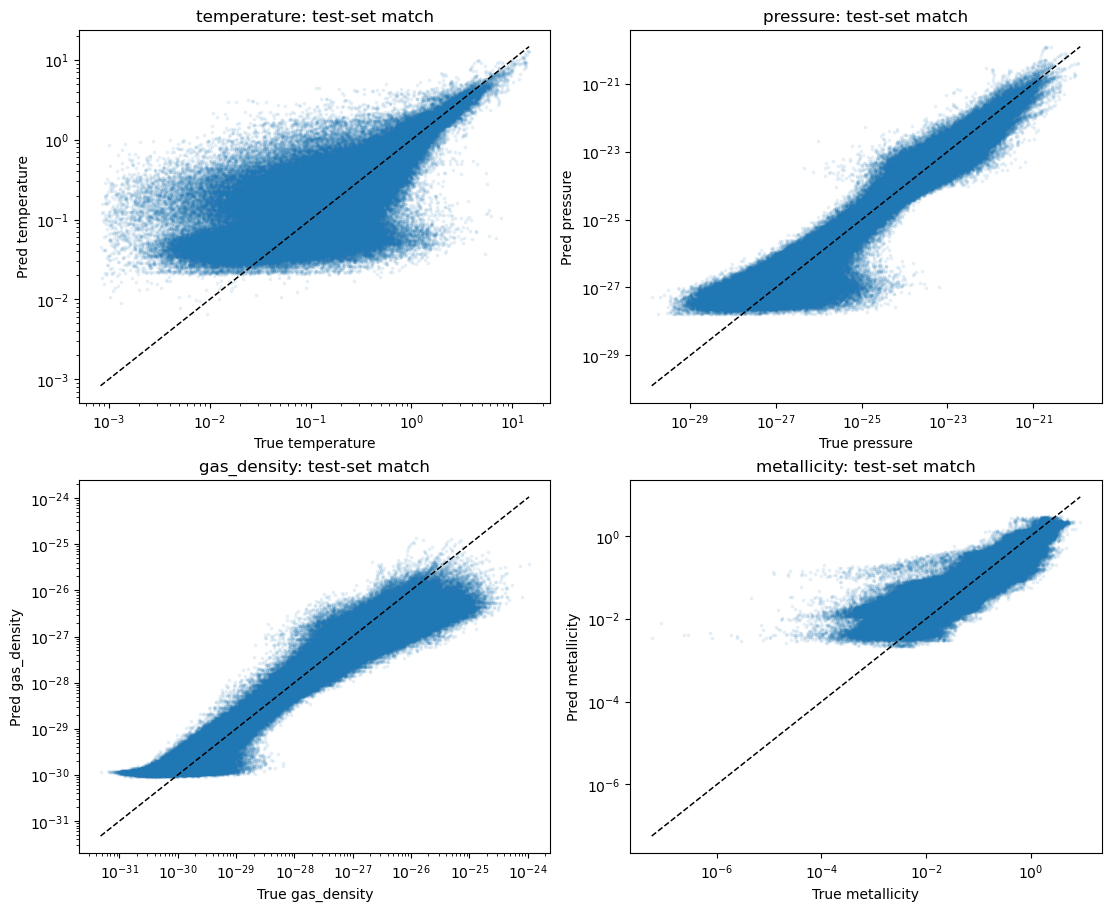

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9), constrained_layout=True)
axes = np.asarray(axes).ravel()

for ax, fname in zip(axes, target_fields):
    d = diag_df[(diag_df['field'] == fname) & (diag_df['true'] > 0) & (diag_df['pred'] > 0)]
    if len(d) == 0:
        ax.text(0.5, 0.5, 'No positive points', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(fname)
        continue
    ax.scatter(d['true'], d['pred'], s=3, alpha=0.08, rasterized=True)
    lo = float(min(d['true'].min(), d['pred'].min()))
    hi = float(max(d['true'].max(), d['pred'].max()))
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1.1)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(f'True {fname}')
    ax.set_ylabel(f'Pred {fname}')
    ax.set_title(f'{fname}: test-set match')

for ax in axes[len(target_fields):]:
    ax.set_visible(False)

plt.show()

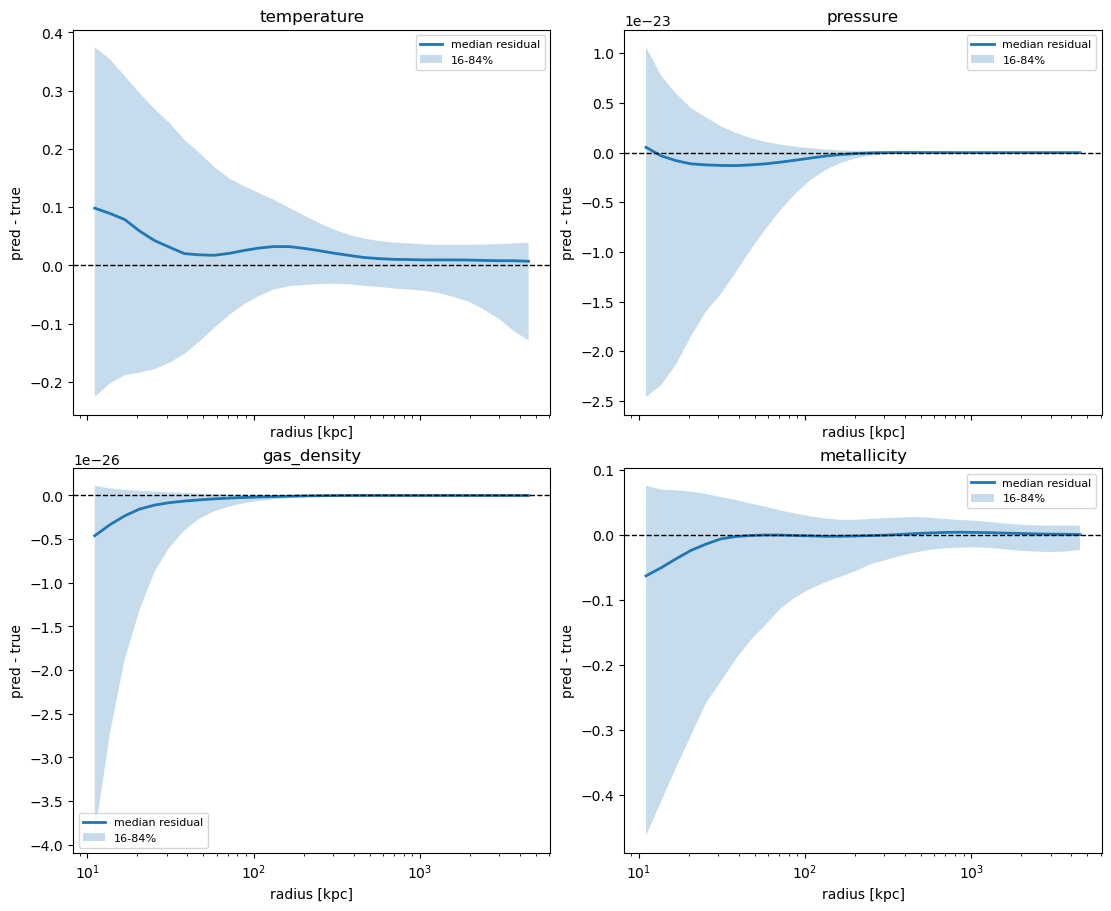

In [15]:
def residual_vs_radius(profile_cache, field_name, q=(0.16, 0.5, 0.84)):
    ys_true = []
    ys_pred = []
    rb = None
    for rec in profile_cache:
        rb = rec['radial_bins']
        j = rec['field_names'].index(field_name)
        ys_true.append(rec['y_true'][:, :, j])
        ys_pred.append(rec['y_pred'][:, :, j])
    yt = np.vstack(ys_true)
    yp = np.vstack(ys_pred)
    resid = yp - yt
    qq = np.quantile(resid, q=np.asarray(q), axis=0)
    return rb, qq

fig, axes = plt.subplots(2, 2, figsize=(11, 9), constrained_layout=True, sharex=True)
axes = np.asarray(axes).ravel()

for ax, fname in zip(axes, target_fields):
    r, qq = residual_vs_radius(profile_cache, fname)
    ax.plot(r, qq[1], lw=2, label='median residual')
    ax.fill_between(r, qq[0], qq[2], alpha=0.25, label='16-84%')
    ax.axhline(0.0, color='k', ls='--', lw=1)
    ax.set_xscale('log')
    ax.set_xlabel('radius [kpc]')
    ax.set_ylabel('pred - true')
    ax.set_title(fname)
    ax.legend(fontsize=8)

for ax in axes[len(target_fields):]:
    ax.set_visible(False)

plt.show()

Evaluation snapshot: 90 (z=0.000)
Test runs: 102, total halos: 12574, valid mass bins: 6
  10^12.05 - 10^12.42: 2096 halos, M_med=10^12.37
  10^12.42 - 10^12.52: 2095 halos, M_med=10^12.46
  10^12.52 - 10^12.64: 2095 halos, M_med=10^12.58
  10^12.64 - 10^12.80: 2095 halos, M_med=10^12.71
  10^12.80 - 10^13.09: 2095 halos, M_med=10^12.93
  10^13.09 - 10^14.85: 2096 halos, M_med=10^13.33


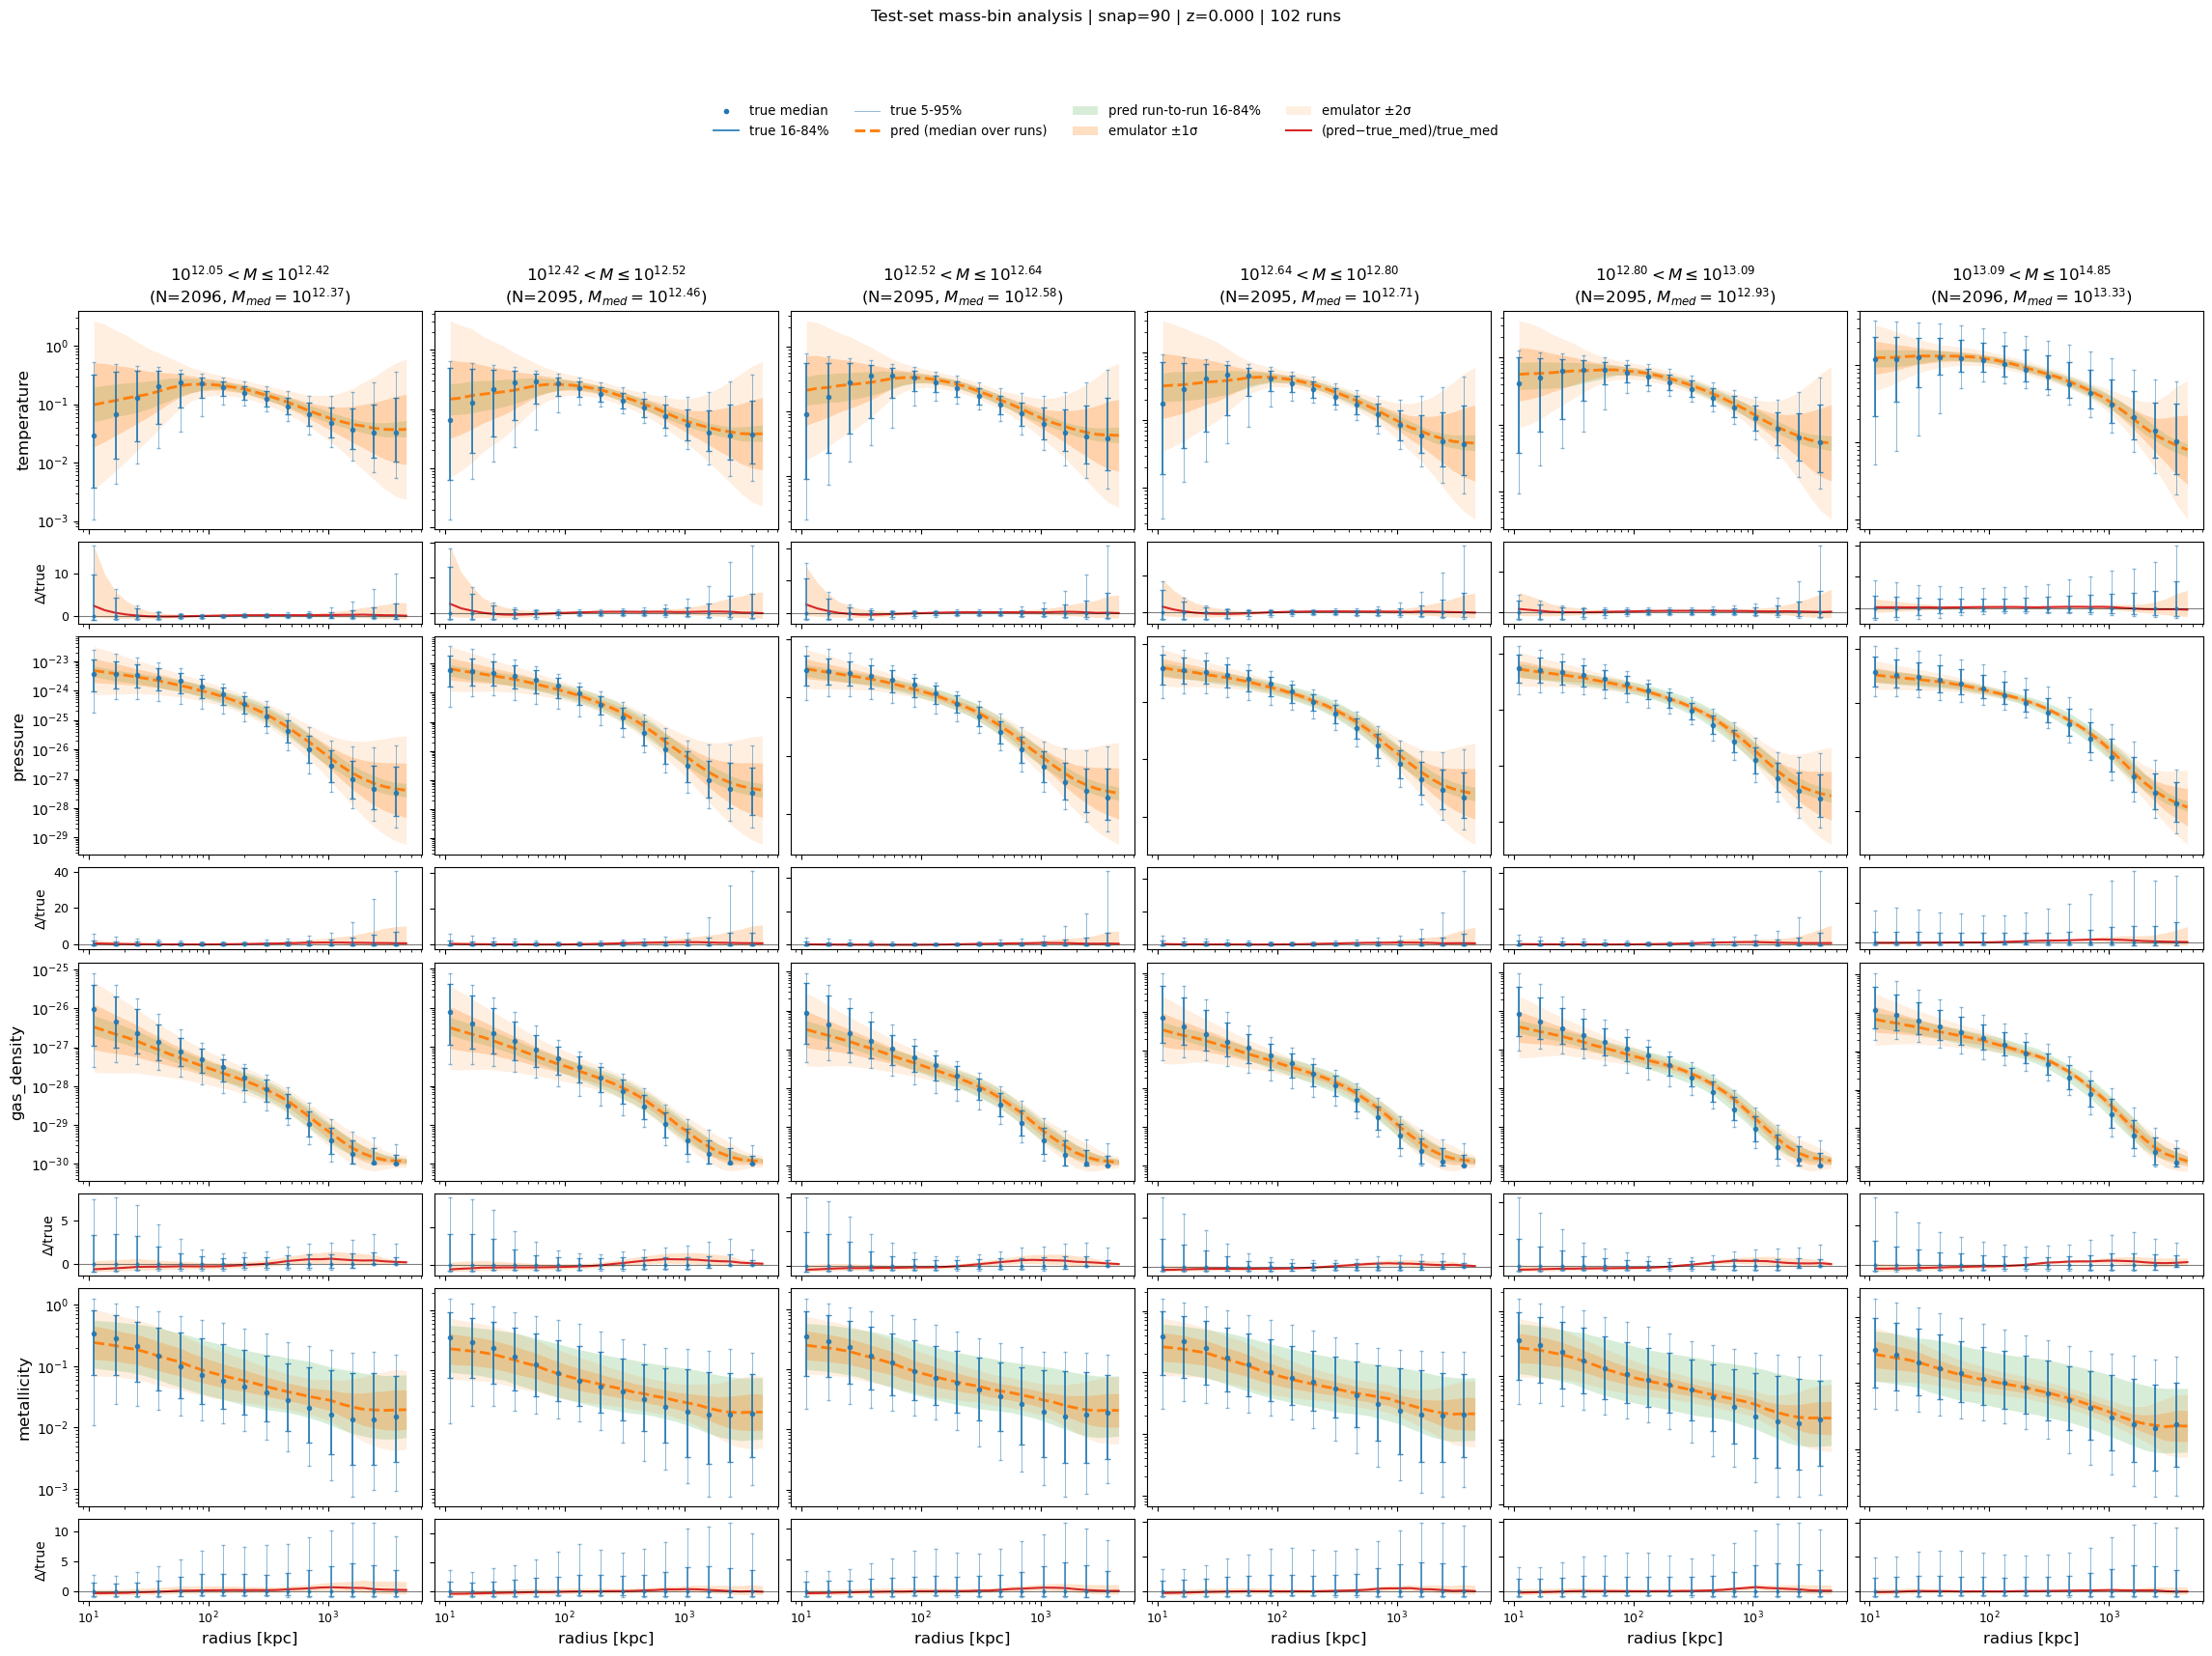

102 test runs, 12574 total halos, 6 valid mass bins.


,field,mass_bin,n_halos,n_runs,median_abs_log10_resid,median_abs_rel_diff_pct
0,gas_density,10^12.05-10^12.42,2096,102,0.163096,34.695891
1,gas_density,10^12.42-10^12.52,2095,102,0.178728,35.612003
2,gas_density,10^12.52-10^12.64,2095,102,0.181633,38.286804
3,gas_density,10^12.64-10^12.80,2095,102,0.159175,35.901244
4,gas_density,10^12.80-10^13.09,2095,102,0.175466,41.341368
5,gas_density,10^13.09-10^14.85,2096,102,0.139855,33.335702
6,metallicity,10^12.05-10^12.42,2096,102,0.104343,25.843260
7,metallicity,10^12.42-10^12.52,2095,102,0.060473,13.820563
8,metallicity,10^12.52-10^12.64,2095,102,0.053903,13.214686
9,metallicity,10^12.64-10^12.80,2095,102,0.038597,8.734320


In [16]:
# Mass-bin analysis: single-halo prediction at bin-median mass vs true halo scatter.
# For each mass bin, predict ONE halo per test run at the bin-median mass,
# then compare median prediction ± spread against true halo scatter.

N_MASS_BINS = 6
LOGM_START = 12.0
MIN_COUNT_PER_BIN = 20
N_SAMPLES_BINS = 30
eps = 1e-30

if len(profile_cache) == 0:
    raise RuntimeError('profile_cache is empty. Run the per-run metrics cell first.')

# ---- Pool all test-set halos from profile_cache ----
all_logm = []
all_masses = []
all_r500c = []
all_true = {f: [] for f in target_fields}
per_run_theta = []

for rec in profile_cache:
    m = rec['M500c'].astype(np.float64)
    all_masses.append(m)
    all_r500c.append(rec['R500c'].astype(np.float64))
    all_logm.append(np.log10(np.clip(m, 1e-30, None)))
    for j, f in enumerate(target_fields):
        all_true[f].append(rec['y_true'][:, :, j])
    per_run_theta.append({
        'run_id': rec['run_id'],
        'theta': rec['theta'],
    })

all_logm = np.concatenate(all_logm)
all_masses = np.concatenate(all_masses)
all_r500c = np.concatenate(all_r500c)
for f in target_fields:
    all_true[f] = np.vstack(all_true[f])

radial_ref = profile_cache[0]['radial_bins'].astype(np.float64)

# ---- Build quantile-based mass bins ----
pool = all_logm[all_logm >= LOGM_START]
if pool.size < max(2, N_MASS_BINS):
    pool = all_logm.copy()
edges = np.unique(np.quantile(pool, np.linspace(0.0, 1.0, N_MASS_BINS + 1)))
if edges.size < N_MASS_BINS + 1:
    lo_e = max(LOGM_START, float(np.nanmin(all_logm)))
    hi_e = float(np.nanmax(all_logm))
    edges = np.linspace(lo_e, hi_e if hi_e > lo_e else lo_e + 0.2, N_MASS_BINS + 1)

n_bins = len(edges) - 1

bin_info = []
for i_bin in range(n_bins):
    lo, hi = edges[i_bin], edges[i_bin + 1]
    if i_bin < n_bins - 1:
        sel = (all_logm >= lo) & (all_logm < hi)
    else:
        sel = (all_logm >= lo) & (all_logm <= hi)
    n_in = int(np.sum(sel))
    if n_in >= MIN_COUNT_PER_BIN:
        bin_info.append({
            'lo': lo, 'hi': hi, 'n_halos': n_in,
            'med_mass': float(np.median(all_masses[sel])),
            'med_r500': float(np.median(all_r500c[sel])),
            'true_in_bin': {f: all_true[f][sel] for f in target_fields},
        })

if len(bin_info) == 0:
    raise RuntimeError(f'No mass bins satisfy N >= {MIN_COUNT_PER_BIN}.')

print(f'Evaluation snapshot: {snap_eval} (z={z_eval:.3f})')
print(f'Test runs: {len(per_run_theta)}, total halos: {len(all_logm)}, valid mass bins: {len(bin_info)}')
for b in bin_info:
    print(f"  10^{b['lo']:.2f} - 10^{b['hi']:.2f}: {b['n_halos']} halos, "
          f"M_med=10^{np.log10(b['med_mass']):.2f}")

# ---- Predict single halo per bin per test run ----
single_masses = np.array([b['med_mass'] for b in bin_info], dtype=np.float32)
single_r500 = np.array([b['med_r500'] for b in bin_info], dtype=np.float64)
single_rr500 = (radial_ref[None, :] / np.maximum(single_r500[:, None], 1e-12)).astype(np.float32)

pred_per_run = []
for rec in per_run_theta:
    try:
        pred = emu.predict(
            theta=rec['theta'],
            M=single_masses,
            r_bins=single_rr500,
            field=target_fields,
            snapnum=snap_eval,
            n_samples=N_SAMPLES_BINS,
        )
    except TypeError:
        pred = emu.predict(
            theta=rec['theta'],
            M=single_masses,
            r_bins=single_rr500,
            field=target_fields,
            n_samples=N_SAMPLES_BINS,
        )
    pred_per_run.append(pred)

# ---- Plot: rows = fields (main + residual), cols = mass bins ----
n_fields = len(target_fields)
n_cols = len(bin_info)
n_rows_total = 2 * n_fields
height_ratios = []
for _ in range(n_fields):
    height_ratios.extend([3.2, 1.2])

title_fs = 13
label_fs = 12
tick_fs = 10

fig, axes = plt.subplots(
    n_rows_total, n_cols,
    figsize=(3.8 * n_cols, 3.6 * n_fields),
    constrained_layout=True,
    sharex='col',
    gridspec_kw={'height_ratios': height_ratios},
)
if n_rows_total == 1 and n_cols == 1:
    axes = np.array([[axes]])
elif n_rows_total == 1:
    axes = np.array([axes])
elif n_cols == 1:
    axes = np.array(axes).reshape(n_rows_total, 1)

step = max(1, radial_ref.size // 14)
idx = np.arange(0, radial_ref.size, step)

massbin_summary_rows = []

for j_col, binfo in enumerate(bin_info):
    lo_e, hi_e = binfo['lo'], binfo['hi']
    axes[0, j_col].set_title(
        rf'$10^{{{lo_e:.2f}}} < M \leq 10^{{{hi_e:.2f}}}$'
        f'\n(N={binfo["n_halos"]}, '
        rf'$M_{{med}}=10^{{{np.log10(binfo["med_mass"]):.2f}}}$)',
        fontsize=title_fs - 1,
    )

    for i_fld, fld in enumerate(target_fields):
        ax_main = axes[2 * i_fld, j_col]
        ax_res = axes[2 * i_fld + 1, j_col]

        # True halo profiles in this bin.
        true_bin = np.clip(binfo['true_in_bin'][fld], eps, None)
        true_med = np.median(true_bin, axis=0)
        true_q16 = np.quantile(true_bin, 0.16, axis=0)
        true_q84 = np.quantile(true_bin, 0.84, axis=0)
        true_q05 = np.quantile(true_bin, 0.05, axis=0)
        true_q95 = np.quantile(true_bin, 0.95, axis=0)

        # Single-halo predictions across test runs: collect per-run profiles.
        pred_profiles = []
        pred_std_log_profiles = []
        for pred in pred_per_run:
            fld_idx = list(pred.field_names).index(fld)
            pred_mu_i = np.asarray(pred.mean[j_col, :, fld_idx], dtype=np.float64)
            pred_profiles.append(pred_mu_i)
            if pred.std_log10 is not None:
                pred_std_log_profiles.append(
                    np.asarray(pred.std_log10[j_col, :, fld_idx], dtype=np.float64)
                )
            else:
                pred_std_i = np.asarray(pred.total_std[j_col, :, fld_idx], dtype=np.float64)
                pred_std_log_profiles.append(
                    np.log10(np.e) * pred_std_i / np.clip(pred_mu_i, eps, None)
                )

        pred_arr = np.asarray(pred_profiles, dtype=np.float64)
        pred_mu = np.median(pred_arr, axis=0)
        pred_q16_run = np.quantile(pred_arr, 0.16, axis=0)
        pred_q84_run = np.quantile(pred_arr, 0.84, axis=0)

        # Median emulator uncertainty in log10 space.
        sd_log = np.median(np.asarray(pred_std_log_profiles, dtype=np.float64), axis=0)
        log_pred = np.log10(np.clip(pred_mu, eps, None))
        pred_lo1 = 10.0 ** (log_pred - sd_log)
        pred_hi1 = 10.0 ** (log_pred + sd_log)
        pred_lo2 = 10.0 ** (log_pred - 2 * sd_log)
        pred_hi2 = 10.0 ** (log_pred + 2 * sd_log)

        # Metrics for this bin/field.
        log_resid = np.log10(np.clip(pred_mu, eps, None)) - np.log10(np.clip(true_med, eps, None))
        rel_diff = (pred_mu - true_med) / np.clip(true_med, eps, None)
        massbin_summary_rows.append({
            'field': fld,
            'mass_bin': f'10^{lo_e:.2f}-10^{hi_e:.2f}',
            'n_halos': binfo['n_halos'],
            'n_runs': len(pred_per_run),
            'median_abs_log10_resid': float(np.median(np.abs(log_resid))),
            'median_abs_rel_diff_pct': float(100.0 * np.median(np.abs(rel_diff))),
        })

        # --- Main panel ---
        err_outer = np.array([
            true_med[idx] - true_q05[idx],
            true_q95[idx] - true_med[idx],
        ])
        err_inner = np.array([
            true_med[idx] - true_q16[idx],
            true_q84[idx] - true_med[idx],
        ])
        ax_main.errorbar(
            radial_ref[idx], true_med[idx], yerr=err_outer,
            fmt='none', ecolor='tab:blue', elinewidth=0.7,
            capsize=1.5, alpha=0.5, zorder=2,
        )
        ax_main.errorbar(
            radial_ref[idx], true_med[idx], yerr=err_inner,
            fmt='o', ms=3.0, color='tab:blue', ecolor='tab:blue',
            elinewidth=1.4, capsize=2.2, alpha=0.85, zorder=3,
            label='true median',
        )

        # Prediction spread across test runs.
        ax_main.fill_between(radial_ref, pred_q16_run, pred_q84_run,
                             color='tab:green', alpha=0.18, linewidth=0)

        # Emulator uncertainty bands.
        ax_main.fill_between(radial_ref, pred_lo2, pred_hi2,
                             color='tab:orange', alpha=0.12, linewidth=0)
        ax_main.fill_between(radial_ref, pred_lo1, pred_hi1,
                             color='tab:orange', alpha=0.25, linewidth=0)
        ax_main.plot(radial_ref, pred_mu, color='tab:orange', lw=2.1, ls='--',
                     label='pred median (over runs)')

        ax_main.set_xscale('log')
        ax_main.set_yscale('log')
        ax_main.tick_params(axis='both', which='both', labelsize=tick_fs)

        # --- Residual panel ---
        denom = np.clip(true_med, eps, None)
        rel = (pred_mu - true_med) / denom

        frac_outer = np.array([
            (true_med[idx] - true_q05[idx]) / denom[idx],
            (true_q95[idx] - true_med[idx]) / denom[idx],
        ])
        frac_inner = np.array([
            (true_med[idx] - true_q16[idx]) / denom[idx],
            (true_q84[idx] - true_med[idx]) / denom[idx],
        ])
        ax_res.errorbar(
            radial_ref[idx], np.zeros(len(idx)), yerr=frac_outer,
            fmt='none', ecolor='tab:blue', elinewidth=0.7,
            capsize=1.5, alpha=0.5, zorder=2,
        )
        ax_res.errorbar(
            radial_ref[idx], np.zeros(len(idx)), yerr=frac_inner,
            fmt='o', ms=2.0, color='tab:blue', ecolor='tab:blue',
            elinewidth=1.4, capsize=2.2, alpha=0.7, zorder=3,
        )

        emu_frac_lo = (pred_lo1 - pred_mu) / denom
        emu_frac_hi = (pred_hi1 - pred_mu) / denom
        ax_res.fill_between(radial_ref, rel + emu_frac_lo, rel + emu_frac_hi,
                            color='tab:orange', alpha=0.22, linewidth=0)
        ax_res.plot(radial_ref, rel, color='tab:red', lw=1.5)
        ax_res.axhline(0.0, color='k', lw=0.8, alpha=0.5)

        ax_res.set_xscale('log')
        ax_res.tick_params(axis='both', which='both', labelsize=max(8, tick_fs - 1))

        if j_col == 0:
            ax_main.set_ylabel(fld, fontsize=label_fs)
            ax_res.set_ylabel('\u0394/true', fontsize=max(9, label_fs - 2))
        else:
            ax_main.set_ylabel('')
            ax_res.set_ylabel('')
            ax_main.tick_params(labelleft=False)
            ax_res.tick_params(labelleft=False)

        if i_fld == n_fields - 1:
            ax_res.set_xlabel('radius [kpc]', fontsize=label_fs)

legend_handles = [
    plt.Line2D([0], [0], color='tab:blue', marker='o', ms=3, lw=0,
               label='true median'),
    plt.Line2D([0], [0], color='tab:blue', lw=1.4, alpha=0.85,
               label='true 16-84%'),
    plt.Line2D([0], [0], color='tab:blue', lw=0.7, alpha=0.5,
               label='true 5-95%'),
    plt.Line2D([0], [0], color='tab:orange', lw=2.1, ls='--',
               label='pred (median over runs)'),
    plt.Rectangle((0, 0), 1, 1, fc='tab:green', alpha=0.18,
                  label='pred run-to-run 16-84%'),
    plt.Rectangle((0, 0), 1, 1, fc='tab:orange', alpha=0.25,
                  label='emulator \u00b11\u03c3'),
    plt.Rectangle((0, 0), 1, 1, fc='tab:orange', alpha=0.12,
                  label='emulator \u00b12\u03c3'),
    plt.Line2D([0], [0], color='tab:red', lw=1.5,
               label='(pred\u2212true_med)/true_med'),
]
fig.legend(
    handles=legend_handles, loc='upper center', ncol=4,
    frameon=False, bbox_to_anchor=(0.5, 1.12), fontsize=9.5,
)
fig.suptitle(
    f'Test-set mass-bin analysis | snap={snap_eval} | z={z_eval:.3f} | {len(per_run_theta)} runs',
    y=1.18,
)
plt.show()

massbin_summary_df = pd.DataFrame(massbin_summary_rows)
print(f'{len(per_run_theta)} test runs, {len(all_logm)} total halos, {len(bin_info)} valid mass bins.')
display(massbin_summary_df.sort_values(['field', 'mass_bin']).reset_index(drop=True))

In [17]:
# Per-run mass-bin RMSE(log10) breakdown.
# For each test run, compare the per-halo prediction at the run's actual masses
# (from profile_cache) against truth, broken down by mass bin.

per_run_massbin_rows = []

for rec in profile_cache:
    run_id = rec['run_id']
    m = rec['M500c'].astype(np.float64)
    logm = np.log10(np.clip(m, 1e-30, None))
    y_true_run = rec['y_true']
    y_pred_run = rec['y_pred']

    for i_bin, binfo in enumerate(bin_info):
        lo_e, hi_e = binfo['lo'], binfo['hi']
        if i_bin < len(bin_info) - 1:
            sel = (logm >= lo_e) & (logm < hi_e)
        else:
            sel = (logm >= lo_e) & (logm <= hi_e)

        n_in = int(np.sum(sel))
        if n_in == 0:
            continue

        for j, fld in enumerate(target_fields):
            yt = np.clip(y_true_run[sel, :, j], eps, None)
            yp = np.clip(y_pred_run[sel, :, j], eps, None)
            valid = np.isfinite(yt) & np.isfinite(yp) & (yt > 0) & (yp > 0)
            if np.any(valid):
                dlog = np.log10(yp[valid]) - np.log10(yt[valid])
                rmse_log10 = float(np.sqrt(np.mean(dlog ** 2)))
            else:
                rmse_log10 = np.nan

            per_run_massbin_rows.append({
                'run_id': run_id,
                'mass_bin': f'10^{lo_e:.2f}-10^{hi_e:.2f}',
                'field': fld,
                'n_halos': n_in,
                'rmse_log10': rmse_log10,
            })

per_run_massbin_df = pd.DataFrame(per_run_massbin_rows)

# Aggregate across runs.
if len(per_run_massbin_df) > 0:
    agg_df = per_run_massbin_df.groupby(['field', 'mass_bin'], as_index=False).agg(
        n_runs=('run_id', 'nunique'),
        total_halos=('n_halos', 'sum'),
        rmse_log10_mean=('rmse_log10', 'mean'),
        rmse_log10_median=('rmse_log10', 'median'),
    ).sort_values(['field', 'mass_bin'])
    print(f'Per-run mass-bin RMSE(log10) | snap={snap_eval} | z={z_eval:.3f}')
    display(agg_df.reset_index(drop=True))
else:
    print('No per-run mass-bin metrics computed.')

Per-run mass-bin RMSE(log10) | snap=90 | z=0.000


,field,mass_bin,n_runs,total_halos,rmse_log10_mean,rmse_log10_median
0,gas_density,10^12.05-10^12.42,101,2096,0.385576,0.371667
1,gas_density,10^12.42-10^12.52,99,2095,0.380922,0.358373
2,gas_density,10^12.52-10^12.64,98,2095,0.370873,0.357365
3,gas_density,10^12.64-10^12.80,99,2095,0.344734,0.331685
4,gas_density,10^12.80-10^13.09,100,2095,0.328092,0.300910
5,gas_density,10^13.09-10^14.85,96,2096,0.270561,0.243751
6,metallicity,10^12.05-10^12.42,101,2096,1.074006,0.475721
7,metallicity,10^12.42-10^12.52,99,2095,0.872495,0.403213
8,metallicity,10^12.52-10^12.64,98,2095,0.692407,0.350678
9,metallicity,10^12.64-10^12.80,99,2095,0.636618,0.339141


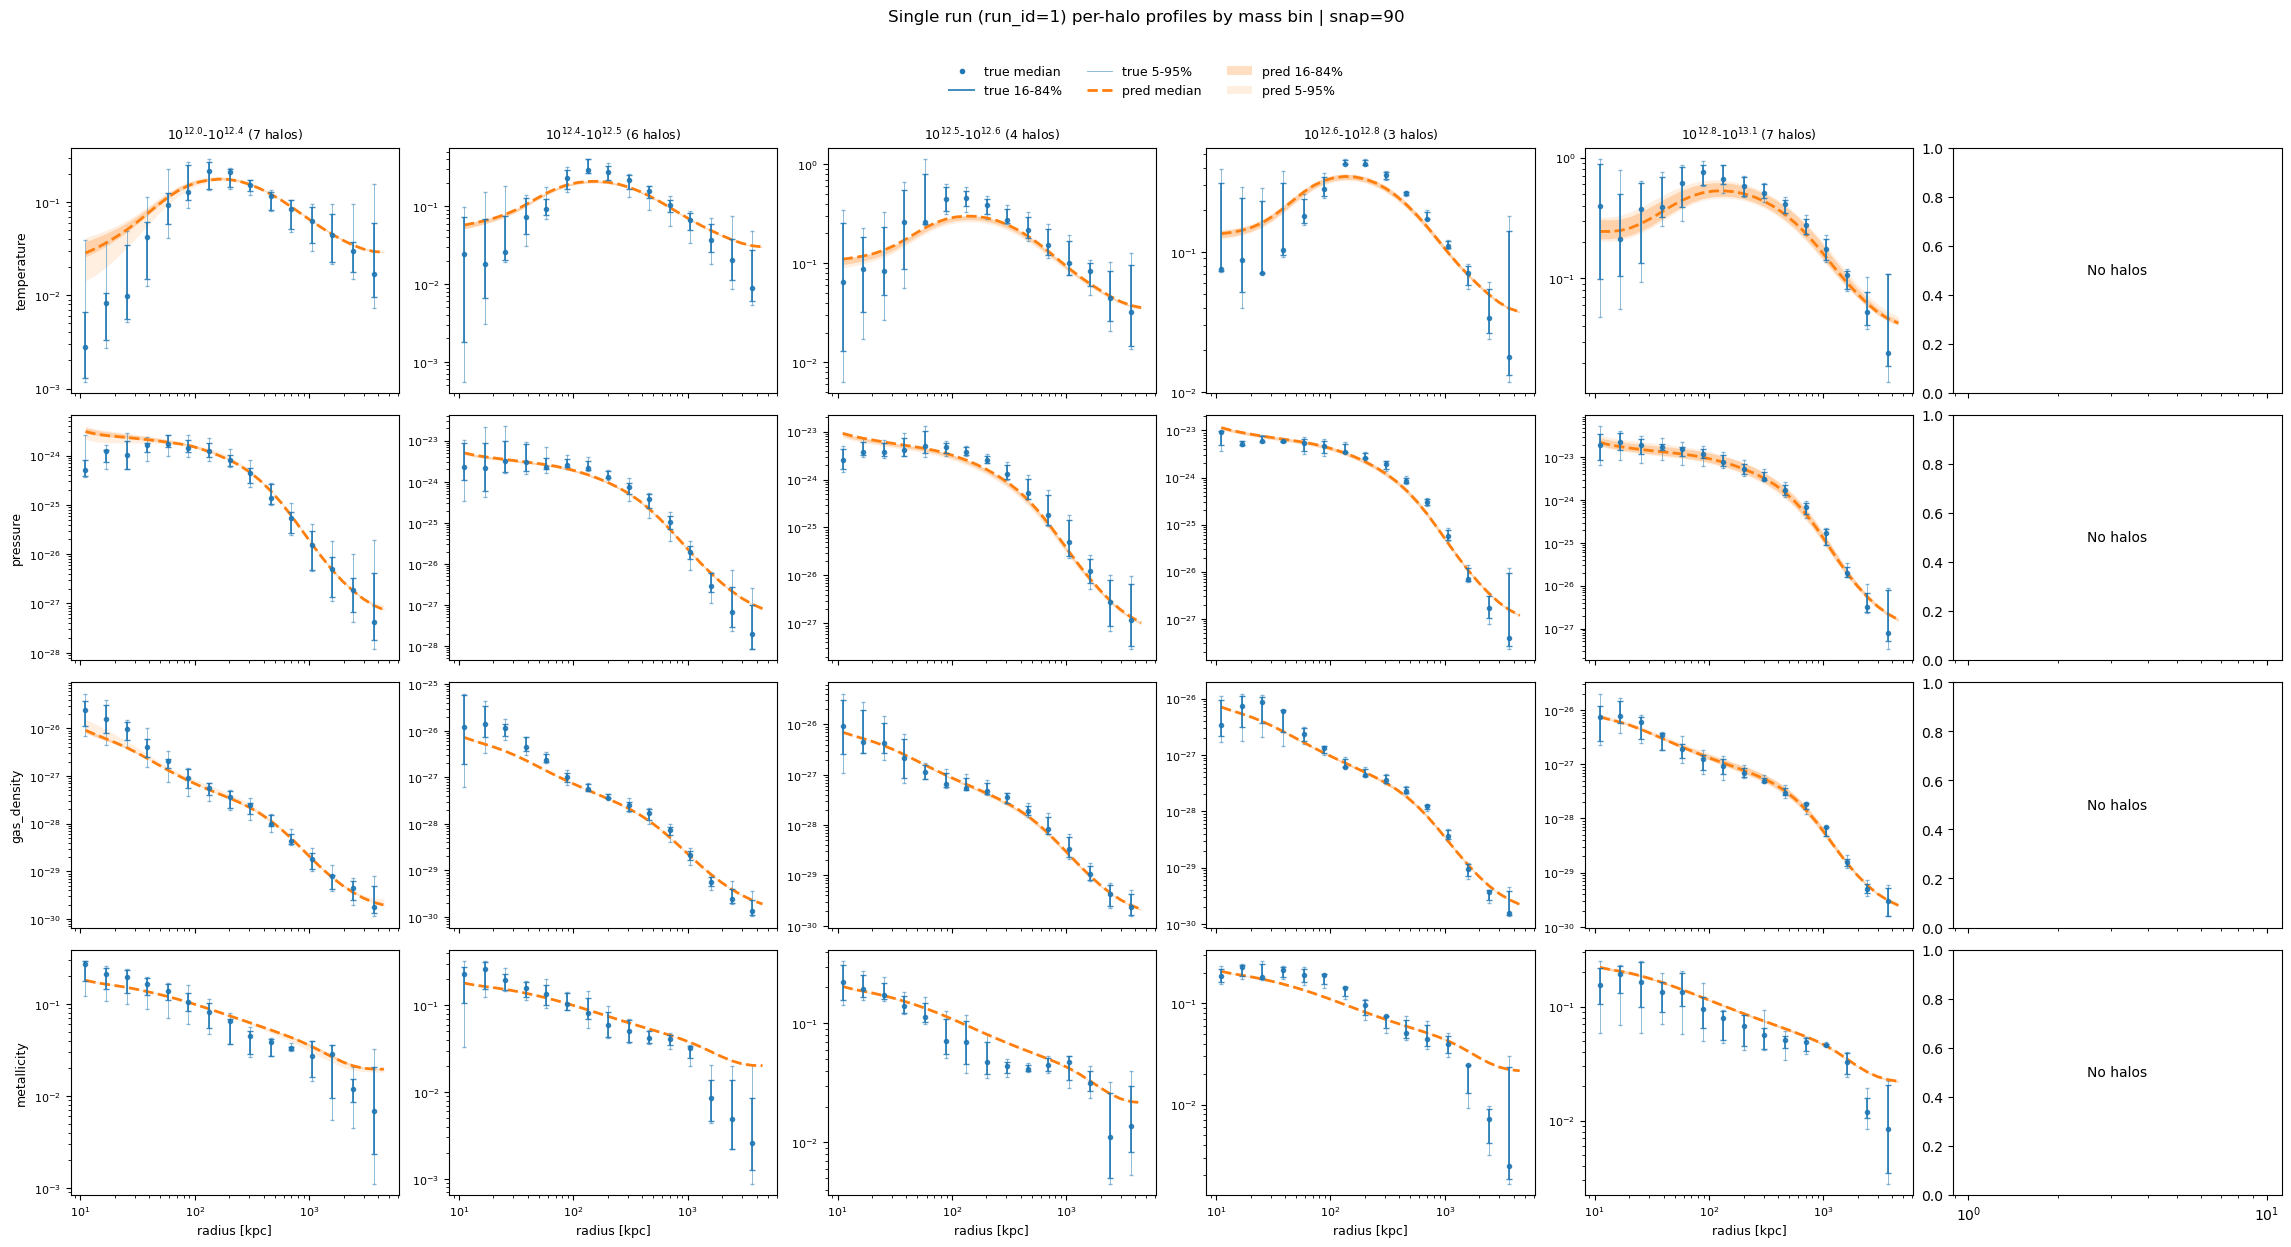

In [19]:
# Single-run example: truth as points with error bars, prediction as line with shaded contours.

if len(profile_cache) == 0:
    raise RuntimeError('profile_cache is empty.')

# Use the first test run.
ex = profile_cache[0]
ex_run = ex['run_id']
ex_m = ex['M500c'].astype(np.float64)
ex_logm = np.log10(np.clip(ex_m, 1e-30, None))
ex_r = ex['radial_bins'].astype(np.float64)

step_eb = max(1, ex_r.size // 14)
idx_eb = np.arange(0, ex_r.size, step_eb)

n_cols = len(bin_info)
fig, axes = plt.subplots(len(target_fields), n_cols, figsize=(3.8 * n_cols, 2.8 * len(target_fields)),
                         constrained_layout=True, sharex='col')
axes = np.atleast_2d(axes)
if len(target_fields) == 1:
    axes = axes.reshape(1, n_cols)
if n_cols == 1:
    axes = axes.reshape(len(target_fields), 1)

for j_col, binfo in enumerate(bin_info):
    lo_e, hi_e = binfo['lo'], binfo['hi']
    if j_col < len(bin_info) - 1:
        sel = (ex_logm >= lo_e) & (ex_logm < hi_e)
    else:
        sel = (ex_logm >= lo_e) & (ex_logm <= hi_e)

    for i_fld, fld in enumerate(target_fields):
        ax = axes[i_fld, j_col]
        if np.sum(sel) == 0:
            ax.text(0.5, 0.5, 'No halos', ha='center', va='center', transform=ax.transAxes)
            ax.set_xscale('log')
            continue

        yt = np.clip(ex['y_true'][sel, :, i_fld], eps, None)
        yp = np.clip(ex['y_pred'][sel, :, i_fld], eps, None)

        # Truth: median with 16-84% and 5-95% error bars (points)
        true_med = np.median(yt, axis=0)
        true_q16 = np.quantile(yt, 0.16, axis=0)
        true_q84 = np.quantile(yt, 0.84, axis=0)
        true_q05 = np.quantile(yt, 0.05, axis=0)
        true_q95 = np.quantile(yt, 0.95, axis=0)

        err_outer = np.array([
            true_med[idx_eb] - true_q05[idx_eb],
            true_q95[idx_eb] - true_med[idx_eb],
        ])
        err_inner = np.array([
            true_med[idx_eb] - true_q16[idx_eb],
            true_q84[idx_eb] - true_med[idx_eb],
        ])
        ax.errorbar(
            ex_r[idx_eb], true_med[idx_eb], yerr=err_outer,
            fmt='none', ecolor='tab:blue', elinewidth=0.7,
            capsize=1.5, alpha=0.5, zorder=2,
        )
        ax.errorbar(
            ex_r[idx_eb], true_med[idx_eb], yerr=err_inner,
            fmt='o', ms=3.0, color='tab:blue', ecolor='tab:blue',
            elinewidth=1.4, capsize=2.2, alpha=0.85, zorder=3,
            label='true median',
        )

        # Prediction: median line with 16-84% and 5-95% shaded contours
        pred_med = np.median(yp, axis=0)
        pred_q16 = np.quantile(yp, 0.16, axis=0)
        pred_q84 = np.quantile(yp, 0.84, axis=0)
        pred_q05 = np.quantile(yp, 0.05, axis=0)
        pred_q95 = np.quantile(yp, 0.95, axis=0)

        ax.fill_between(ex_r, pred_q05, pred_q95,
                        color='tab:orange', alpha=0.12, linewidth=0, label='pred 5-95%')
        ax.fill_between(ex_r, pred_q16, pred_q84,
                        color='tab:orange', alpha=0.25, linewidth=0, label='pred 16-84%')
        ax.plot(ex_r, pred_med, color='tab:orange', lw=2, ls='--', label='pred median')

        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.tick_params(labelsize=8)

        if i_fld == 0:
            ax.set_title(rf'$10^{{{lo_e:.1f}}}$-$10^{{{hi_e:.1f}}}$ ({np.sum(sel)} halos)', fontsize=9)
        if j_col == 0:
            ax.set_ylabel(fld, fontsize=9)
        if i_fld == len(target_fields) - 1:
            ax.set_xlabel('radius [kpc]', fontsize=9)

legend_handles = [
    plt.Line2D([0], [0], color='tab:blue', marker='o', ms=3, lw=0, label='true median'),
    plt.Line2D([0], [0], color='tab:blue', lw=1.4, alpha=0.85, label='true 16-84%'),
    plt.Line2D([0], [0], color='tab:blue', lw=0.7, alpha=0.5, label='true 5-95%'),
    plt.Line2D([0], [0], color='tab:orange', lw=2, ls='--', label='pred median'),
    plt.Rectangle((0, 0), 1, 1, fc='tab:orange', alpha=0.25, label='pred 16-84%'),
    plt.Rectangle((0, 0), 1, 1, fc='tab:orange', alpha=0.12, label='pred 5-95%'),
]
fig.legend(handles=legend_handles, loc='upper center', ncol=3, frameon=False,
           bbox_to_anchor=(0.5, 1.06), fontsize=9)
fig.suptitle(f'Single run (run_id={ex_run}) per-halo profiles by mass bin | snap={snap_eval}', y=1.10)
plt.show()